In [7]:
%pip install requests
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import requests
import pandas as pd
from datetime import datetime, timedelta

latitude = 24.8607
longitude = 67.0011

end_date = datetime.utcnow().date()
start_date = end_date - timedelta(days=365 * 2)  # for 2 years

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

# use Open Meteo API to fetch air quality data for Karachi but tokenize the url as it is too long and faces error to fetch such huge data without tokenization
URL = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={latitude}&longitude={longitude}"
    f"&hourly=pm10,pm2_5,carbon_monoxide,ozone,sulphur_dioxide,nitrogen_dioxide"
    f"&start_date={start_date_str}&end_date={end_date_str}"
)

response = requests.get(URL)
if response.status_code == 200:
    data = response.json()
    hourly_data = data.get('hourly', {})
    if hourly_data and hourly_data.get('time'):
        df = pd.DataFrame(hourly_data)
        print(f"Data shape: {df.shape}")
        df.to_csv("karachi_AQI_openmeteo_2years.csv", index=False)
    else:
        print("No hourly data for this location and time period.")
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")


C:\Users\admin\AppData\Local\Temp\ipykernel_6200\4272729817.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_date = datetime.utcnow().date()


Data shape: (17544, 7)


In [5]:
df= pd.read_csv("karachi_AQI_openmeteo_2years.csv")

In [3]:
df.head()

,time,pm10,pm2_5,carbon_monoxide,ozone,sulphur_dioxide,nitrogen_dioxide
0,2023-08-17T00:00,28.5,12.3,108.0,36.0,3.0,4.4
1,2023-08-17T01:00,29.0,12.7,130.0,34.0,3.2,5.7
2,2023-08-17T02:00,31.2,13.5,160.0,32.0,3.6,7.4
3,2023-08-17T03:00,35.2,13.9,178.0,33.0,3.8,8.1
4,2023-08-17T04:00,39.7,13.5,171.0,38.0,3.8,6.9


In [4]:
df.describe()

,pm10,pm2_5,carbon_monoxide,ozone,sulphur_dioxide,nitrogen_dioxide
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,65.247726,27.860026,426.729708,73.098495,11.896403,18.616382
std,38.522104,13.705872,366.968125,38.340258,7.903773,17.318361
min,3.900000,3.800000,46.000000,0.000000,2.300000,0.700000
25%,41.400000,18.700000,202.000000,45.000000,5.600000,7.300000
50%,56.600000,24.200000,288.000000,64.000000,9.900000,12.500000
75%,78.000000,33.100000,526.000000,96.000000,15.800000,23.600000
max,497.300000,117.800000,4302.000000,240.000000,60.600000,154.100000


In [12]:
df.isnull().sum()

time                0
pm10                0
pm2_5               0
carbon_monoxide     0
ozone               0
sulphur_dioxide     0
nitrogen_dioxide    0
dtype: int64

In [8]:
# IQR formula using for removing outliers as there is a huge difference in the data
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

# for numerical columns only
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_cleaned = remove_outliers_iqr(df, num_cols)
print(f"Original shape: {df.shape}")
print(f"Shape after outlier removal: {df_cleaned.shape}")

Original shape: (17544, 7)
Shape after outlier removal: (13170, 7)


In [9]:
df_cleaned.describe()

,pm10,pm2_5,carbon_monoxide,ozone,sulphur_dioxide,nitrogen_dioxide
count,13170.000000,13170.000000,13170.000000,13170.000000,13170.000000,13170.000000
mean,57.816317,22.963303,297.436219,72.715186,9.435961,13.254244
std,24.500039,7.915666,155.568031,32.980504,5.329757,8.508156
min,3.900000,3.800000,46.000000,2.000000,2.300000,0.700000
25%,40.300000,17.300000,187.000000,48.000000,5.100000,6.600000
50%,53.900000,21.500000,249.000000,64.000000,7.800000,10.700000
75%,71.500000,27.100000,362.000000,92.000000,12.800000,17.800000
max,132.700000,51.100000,885.000000,169.000000,26.000000,39.000000


In [6]:
df_cleaned.to_csv("karachi_AQI_openmeteo_2years_cleaned.csv", index=False)

In [11]:
import pandas as pd

df_cleaned = pd.read_csv("karachi_AQI_openmeteo_2years_cleaned.csv")
df_cleaned['time'] = pd.to_datetime(df_cleaned['time'])
df_cleaned['hour'] = df_cleaned['time'].dt.hour
df_cleaned['day'] = df_cleaned['time'].dt.day
df_cleaned['month'] = df_cleaned['time'].dt.month

pollutants = ['pm10', 'pm2_5', 'carbon_monoxide', 'ozone', 'sulphur_dioxide', 'nitrogen_dioxide']

# Lag features
for col in pollutants:
    df_cleaned[f'{col}_lag1'] = df_cleaned[col].shift(1)
    df_cleaned[f'{col}_lag2'] = df_cleaned[col].shift(2)
    df_cleaned[f'{col}_lag3'] = df_cleaned[col].shift(3)

# Rolling features
for col in pollutants:
    for window, suffix in zip([3, 6, 24], ['3h', '6h', '24h']):
        df_cleaned[f'{col}_roll_mean_{suffix}'] = df_cleaned[col].rolling(window=window).mean()
        df_cleaned[f'{col}_roll_max_{suffix}'] = df_cleaned[col].rolling(window=window).max()
        df_cleaned[f'{col}_roll_min_{suffix}'] = df_cleaned[col].rolling(window=window).min()

# Target column (next hour PM2.5)
df_cleaned['target_pm2_5'] = df_cleaned['pm2_5'].shift(-1)

# Drop rows with NaN values created by shifting/rolling
df_features = df_cleaned.dropna().reset_index(drop=True)

# Save the feature-engineered dataset
df_features.to_csv("karachi_AQI_features_engineered.csv", index=False)
print("Feature-engineered dataset saved as karachi_AQI_features_engineered.csv")

Feature-engineered dataset saved as karachi_AQI_features_engineered.csv


In [12]:
df_features.describe()

,time,pm10,pm2_5,carbon_monoxide,ozone,sulphur_dioxide,nitrogen_dioxide,hour,day,month,...,nitrogen_dioxide_roll_mean_3h,nitrogen_dioxide_roll_max_3h,nitrogen_dioxide_roll_min_3h,nitrogen_dioxide_roll_mean_6h,nitrogen_dioxide_roll_max_6h,nitrogen_dioxide_roll_min_6h,nitrogen_dioxide_roll_mean_24h,nitrogen_dioxide_roll_max_24h,nitrogen_dioxide_roll_min_24h,target_pm2_5
count,13146,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000,...,13146.000000,13146.000000,13146.000000,13146.000000,13146.00000,13146.000000,13146.000000,13146.000000,13146.000000,13146.000000
mean,2024-08-21 22:11:34.477407744,57.858291,22.979089,297.698463,72.776738,9.446661,13.266804,11.635174,15.481743,6.528754,...,13.265556,16.115853,10.531279,13.263533,19.55054,7.921763,13.252923,25.822425,4.451301,22.979431
min,2023-08-17 23:00:00,3.900000,3.800000,46.000000,2.000000,2.300000,0.700000,0.000000,1.000000,1.000000,...,2.500000,2.600000,0.700000,2.933333,4.00000,0.700000,4.975000,7.700000,0.700000,3.800000
25%,2024-03-05 18:15:00,40.300000,17.300000,187.250000,48.000000,5.100000,6.600000,6.000000,8.000000,4.000000,...,7.033333,8.600000,5.500000,7.833333,11.30000,4.600000,9.325000,17.300000,3.400000,17.300000
50%,2024-08-12 03:30:00,54.000000,21.500000,249.000000,64.000000,7.800000,10.700000,12.000000,15.000000,7.000000,...,11.000000,13.500000,8.300000,11.600000,17.45000,6.400000,12.629167,25.550000,4.100000,21.500000
75%,2025-03-18 17:00:00,71.500000,27.200000,362.000000,92.000000,12.800000,17.800000,18.000000,23.000000,9.000000,...,17.833333,22.100000,13.800000,17.500000,27.10000,9.700000,16.816667,35.400000,5.200000,27.200000
max,2025-08-16 22:00:00,132.700000,51.100000,885.000000,169.000000,26.000000,39.000000,23.000000,31.000000,12.000000,...,38.433333,39.000000,37.900000,37.050000,39.00000,35.000000,28.995833,39.000000,13.400000,51.100000
std,NaN,24.502047,7.913940,155.563473,32.977094,5.328018,8.509654,7.042199,8.818409,3.059168,...,7.877771,9.404336,6.771269,6.808962,9.62210,4.776813,4.649996,9.450193,1.438482,7.913684


In [10]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13168 entries, 0 to 13167
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    13168 non-null  int64  
 1   pm10                    13168 non-null  float64
 2   pm2_5                   13168 non-null  float64
 3   carbon_monoxide         13168 non-null  float64
 4   ozone                   13168 non-null  float64
 5   sulphur_dioxide         13168 non-null  float64
 6   nitrogen_dioxide        13168 non-null  float64
 7   hour                    13168 non-null  int64  
 8   day                     13168 non-null  int64  
 9   month                   13168 non-null  int64  
 10  pm10_lag1               13168 non-null  float64
 11  pm2_5_lag1              13168 non-null  float64
 12  carbon_monoxide_lag1    13168 non-null  float64
 13  ozone_lag1              13168 non-null  float64
 14  sulphur_dioxide_lag1    13168 non-null

In [15]:
import hopsworks
import pandas as pd

# engineered data
df_features = pd.read_csv("karachi_AQI_features_engineered.csv")
# Convert the 'time' column to a datetime object
df_features['time'] = pd.to_datetime(df_features['time']).astype('int64') // 10**6
# Connect to Hopsworks
project = hopsworks.login(
    project="aqi_features_dataset", 
    # api_key_value="ckDKuQOWxPLxBQfgLGmUtVOMkbUWdeEo"
    api_key_value="t29A93H0Tnz50i2X.44jnj8Zbktd3HhUtXeMsXKBfixNUULLxJRf1XDAr3QUKxAJW3Eax40ZhZ5OmkqQ9"
)

2025-08-16 16:20:43,579 INFO: Closing external client and cleaning up certificates.
Connection closed.
2025-08-16 16:20:43,591 INFO: Initializing external client
Connection closed.
2025-08-16 16:20:43,591 INFO: Initializing external client
2025-08-16 16:20:43,592 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-08-16 16:20:43,592 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-08-16 16:20:45,579 INFO: Python Engine initialized.
2025-08-16 16:20:45,579 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1239213

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1239213


In [16]:
fs = project.get_feature_store()

In [17]:
# Creating Feature Group
feature_group = fs.get_or_create_feature_group(
    name="aqi_feature_group",
    version=1,
    description="Engineered features for hourly Air Quality Index (AQI) prediction in Karachi, including raw pollutant concentrations, time-based features, and various lagged and rolling window statistics.",
    primary_key=["time"],
    event_time="time",  #for time-series data
    online_enabled=True
)

In [18]:
feature_group.insert(df_features,write_options={"wait_for_job": True})

Uploading Dataframe: 100.00% |██████████| Rows 13146/13146 | Elapsed Time: 00:06 | Remaining Time: 00:00



Launching job: aqi_feature_group_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1239213/jobs/named/aqi_feature_group_1_offline_fg_materialization/executions
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1239213/jobs/named/aqi_feature_group_1_offline_fg_materialization/executions
2025-08-16 16:21:26,949 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-08-16 16:21:26,949 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2025-08-16 16:21:30,227 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-08-16 16:21:30,227 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2025-08-16 16:23:18,584 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED
2025-08-16 16:23:18,584 INFO: Wait

(Job('aqi_feature_group_1_offline_fg_materialization', 'SPARK'), None)

In [13]:
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

df = pd.read_csv('karachi_AQI_features_engineered.csv')

#Rename 'time' column to 'date'
df = df.rename(columns={'time': 'date'})

#Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

#date as index for teh dataset
df = df.set_index('date')

#Handle missing values by interpolation
df.interpolate(method='linear', inplace=True)

print(df.head())

                     pm10  pm2_5  carbon_monoxide  ozone  sulphur_dioxide  \
date                                                                        
2023-08-17 23:00:00  31.3   14.8             99.0   35.0              2.5   
2023-08-18 00:00:00  34.1   15.0            103.0   36.0              2.7   
2023-08-18 01:00:00  34.2   14.6            123.0   35.0              2.9   
2023-08-18 02:00:00  36.8   15.1            150.0   34.0              3.2   
2023-08-18 03:00:00  42.7   15.3            167.0   36.0              3.4   

                     nitrogen_dioxide  hour  day  month  pm10_lag1  ...  \
date                                                                ...   
2023-08-17 23:00:00               3.8    23   17      8       31.7  ...   
2023-08-18 00:00:00               3.9     0   18      8       31.3  ...   
2023-08-18 01:00:00               5.0     1   18      8       34.1  ...   
2023-08-18 02:00:00               6.5     2   18      8       34.2  ...   
2023-08-18

In [26]:
df.info()
print(df.shape)
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13146 entries, 2023-08-17 23:00:00 to 2025-08-16 22:00:00
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   pm10                            13146 non-null  float64
 1   pm2_5                           13146 non-null  float64
 2   carbon_monoxide                 13146 non-null  float64
 3   ozone                           13146 non-null  float64
 4   sulphur_dioxide                 13146 non-null  float64
 5   nitrogen_dioxide                13146 non-null  float64
 6   hour                            13146 non-null  int64  
 7   day                             13146 non-null  int64  
 8   month                           13146 non-null  int64  
 9   pm10_lag1                       13146 non-null  float64
 10  pm10_lag2                       13146 non-null  float64
 11  pm10_lag3                       13146 non-null  float64
 1

In [27]:
import pandas as pd

# Load the feature-engineered dataset
df_features = pd.read_csv("karachi_AQI_features_engineered.csv")

# Identify numerical columns
num_cols = df_features.select_dtypes(include=['float64', 'int64']).columns

# Remove outliers using the IQR method
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

df_features_cleaned = remove_outliers_iqr(df_features, num_cols)

# Save the cleaned feature-engineered dataset
df_features_cleaned.to_csv("karachi_AQI_features_engineered_cleaned.csv", index=False)
print("Cleaned feature-engineered dataset saved as karachi_AQI_features_engineered_cleaned.csv")

Cleaned feature-engineered dataset saved as karachi_AQI_features_engineered_cleaned.csv


In [29]:
df = pd.read_csv("karachi_AQI_features_engineered_cleaned.csv")
print(df.shape)
print(df.head())
print(df.describe())
df = df.rename(columns={'target_pm2_5': 'aqi'})

(2961, 83)
                  time  pm10  pm2_5  carbon_monoxide  ozone  sulphur_dioxide  \
0  2023-08-17 23:00:00  31.3   14.8             99.0   35.0              2.5   
1  2023-08-18 00:00:00  34.1   15.0            103.0   36.0              2.7   
2  2023-08-18 01:00:00  34.2   14.6            123.0   35.0              2.9   
3  2023-08-18 02:00:00  36.8   15.1            150.0   34.0              3.2   
4  2023-08-18 03:00:00  42.7   15.3            167.0   36.0              3.4   

   nitrogen_dioxide  hour  day  month  ...  nitrogen_dioxide_roll_mean_3h  \
0               3.8    23   17      8  ...                       4.200000   
1               3.9     0   18      8  ...                       3.933333   
2               5.0     1   18      8  ...                       4.233333   
3               6.5     2   18      8  ...                       5.133333   
4               7.1     3   18      8  ...                       6.200000   

   nitrogen_dioxide_roll_max_3h  nitrogen_dio

Exploratory DATA ANALYSIS

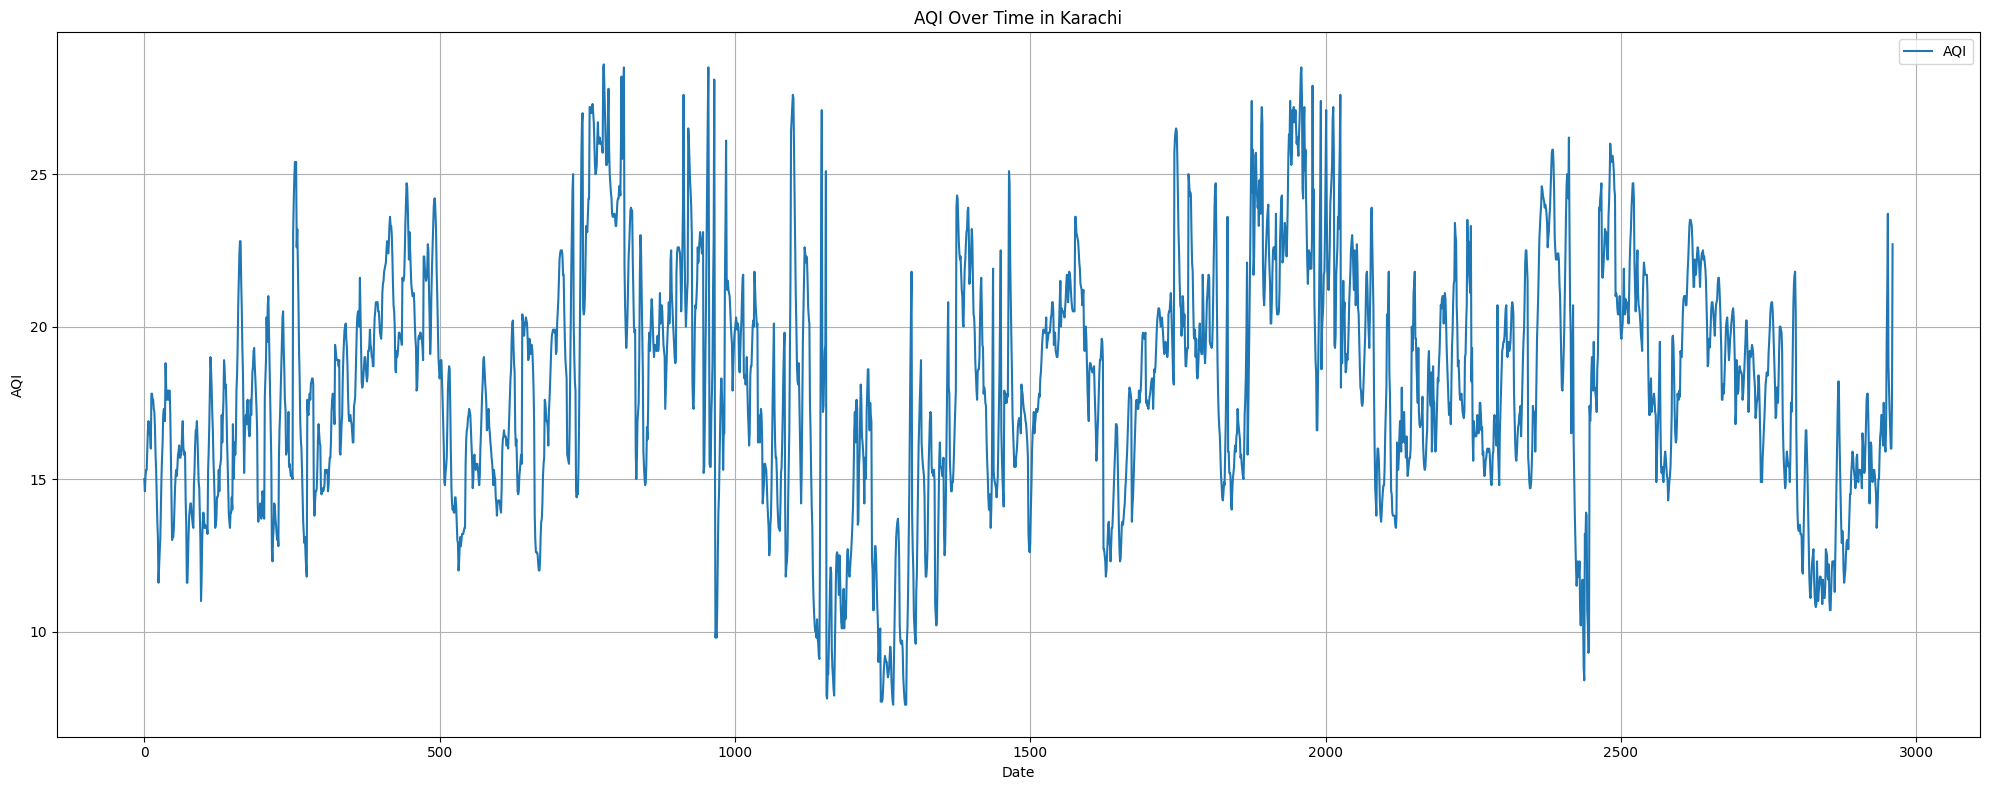

In [30]:
#Time Series Plot of AQI
plt.figure(figsize=(20, 8))
plt.plot(df.index, df['aqi'], label='AQI') # Use df.index since 'date' is now the index
plt.title('AQI Over Time in Karachi')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


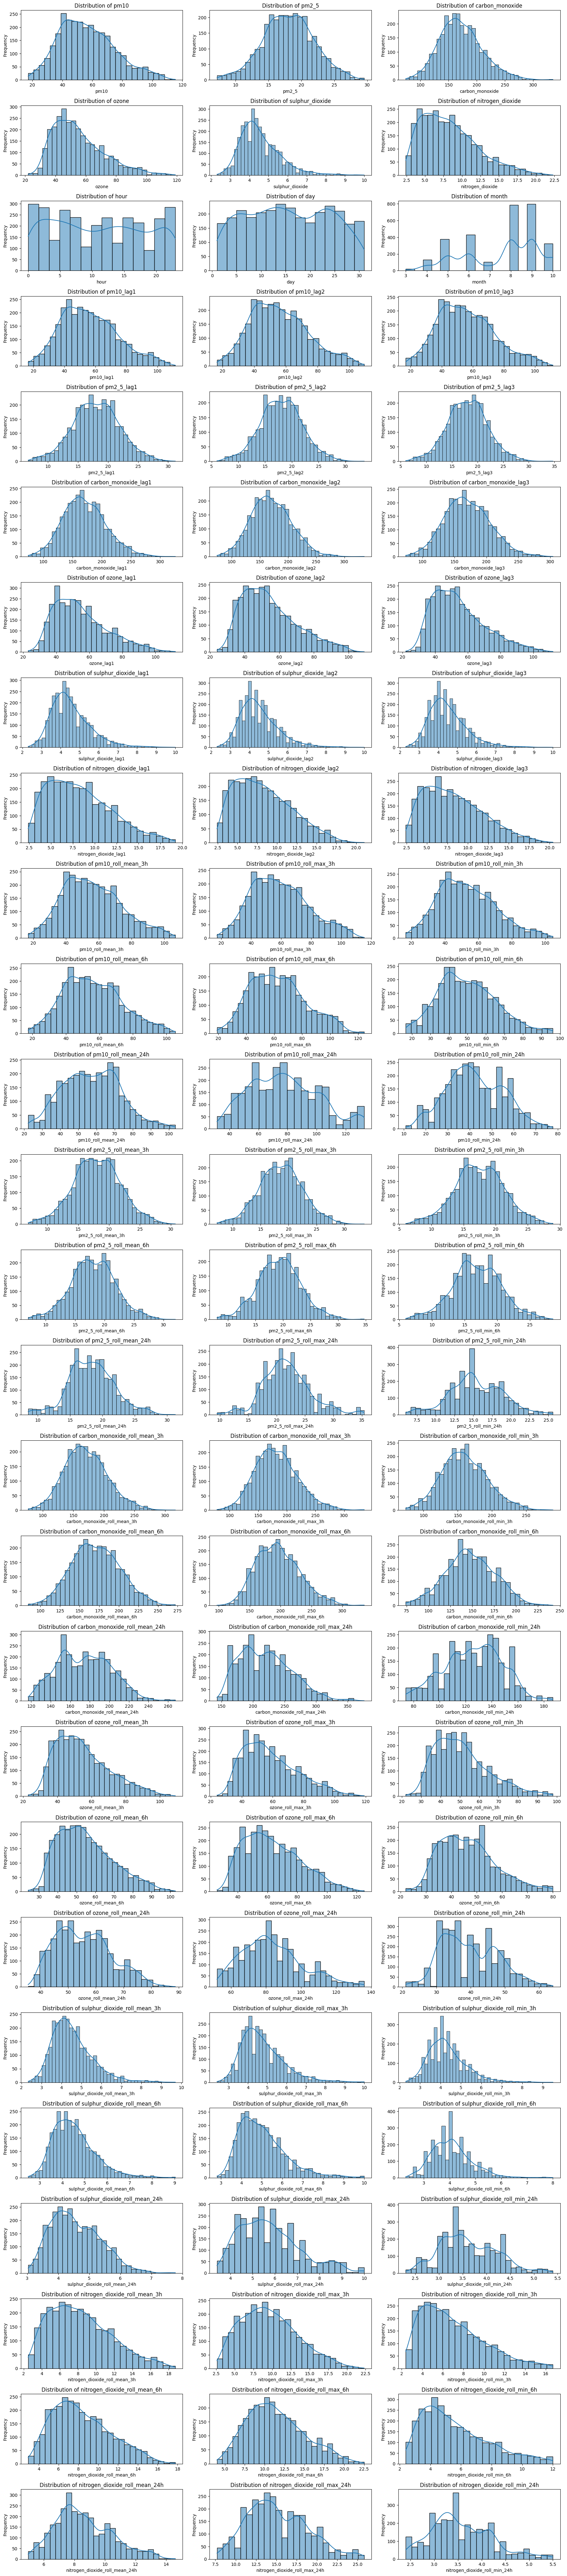

In [31]:
#distributions of Key Numerical Features (excluding 'aqi' target)
numerical_features_for_dist = df.select_dtypes(include=['float64', 'int64']).columns.drop('aqi', errors='ignore')

num_cols_dist = len(numerical_features_for_dist)
n_rows_dist = (num_cols_dist + 3) // 3 # 3 columns per row
plt.figure(figsize=(18, n_rows_dist * 3))

for i, col in enumerate(numerical_features_for_dist):
    plt.subplot(n_rows_dist, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

2025-08-16 17:42:15,377 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-16 17:42:15,392 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-16 17:42:15,646 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-16 17:42:15,678 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-08-16 17:42:16,014 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates

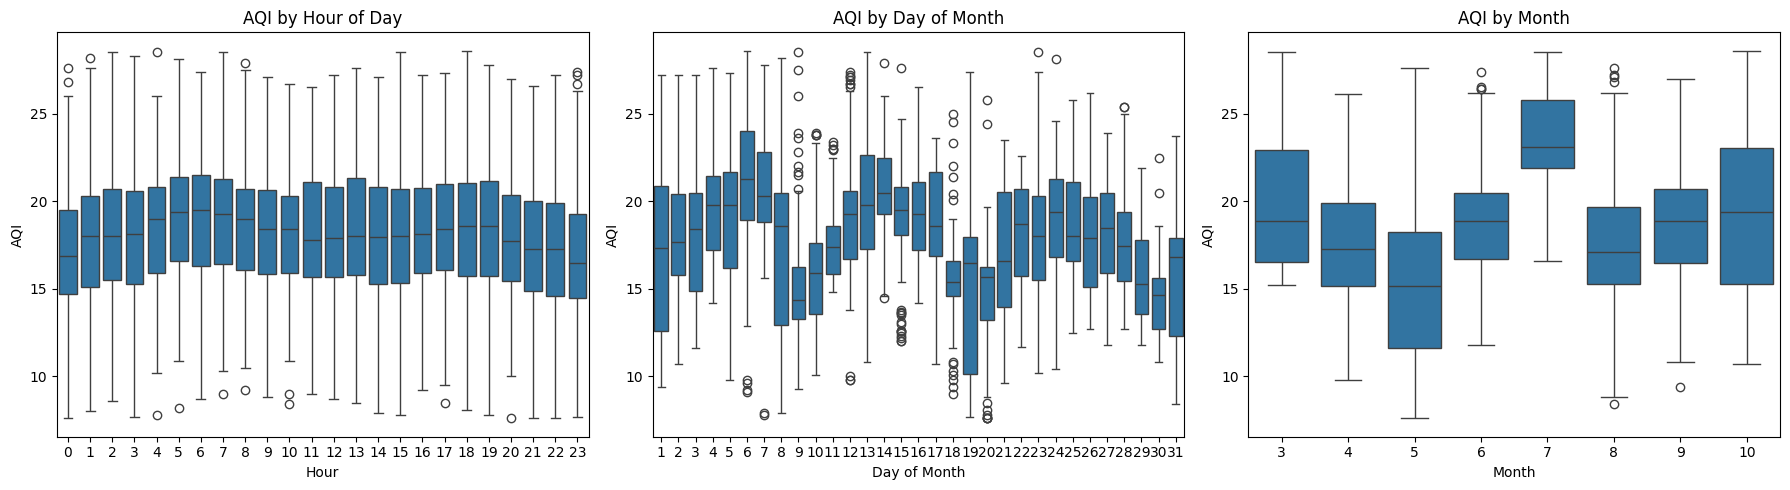


Features (X) shape: (2961, 85)
Target (y) shape: (2961,)
First 5 rows of X:
                 time  pm10  pm2_5  carbon_monoxide  ozone  sulphur_dioxide  \
0 2023-08-17 23:00:00  31.3   14.8             99.0   35.0              2.5   
1 2023-08-18 00:00:00  34.1   15.0            103.0   36.0              2.7   
2 2023-08-18 01:00:00  34.2   14.6            123.0   35.0              2.9   
3 2023-08-18 02:00:00  36.8   15.1            150.0   34.0              3.2   
4 2023-08-18 03:00:00  42.7   15.3            167.0   36.0              3.4   

   nitrogen_dioxide  hour  day  month  ...  nitrogen_dioxide_roll_min_3h  \
0               3.8    23   17      8  ...                           3.8   
1               3.9     0   18      8  ...                           3.8   
2               5.0     1   18      8  ...                           3.8   
3               6.5     2   18      8  ...                           3.9   
4               7.1     3   18      8  ...                          

In [ ]:
# 4. Relationship with Time-Based Features
# Ensure these features are in the DataFrame for plotting.
# If they are already in the CSV, great. If not, create them from the index.
# The 'hour', 'day', 'month' columns are present in your 'karachi_AQI_features_engineered.csv'
# If you want to use the datetime index to extract them again (e.g. if they are missing or for verification):
df['time'] = pd.to_datetime(df['time'])
df['hour_of_day'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek # Monday=0, Sunday=6
df['month_of_year'] = df['time'].dt.month

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='hour', y='aqi', data=df) # Assuming 'hour' column is present after loading
plt.title('AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('AQI')

plt.subplot(1, 3, 2)
sns.boxplot(x='day', y='aqi', data=df) # Assuming 'day' column is present
plt.title('AQI by Day of Month') # Clarified from "Day of Week" to "Day of Month" if 'day' is actual day number
plt.xlabel('Day of Month')
plt.ylabel('AQI')

plt.subplot(1, 3, 3)
sns.boxplot(x='month', y='aqi', data=df) # Assuming 'month' column is present
plt.title('AQI by Month')
plt.xlabel('Month')
plt.ylabel('AQI')

plt.tight_layout()
plt.show()



# --- Feature and Target Definition (after EDA) ---
# X will contain all columns except 'aqi' (target)
# 'date' is now the index, so it won't be in columns for X automatically.
X = df.drop(columns=['aqi'])
y = df['aqi']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("First 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

In [15]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.svm import SVR
# from sklearn.metrics import mean_squared_error as mse 
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import r2_score
# import numpy as np

In [ ]:
# # Define models to test
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge Regression": Ridge(alpha=1.0),
#     "Lasso Regression": Lasso(alpha=0.1),
#     "Decision Tree": DecisionTreeRegressor(random_state=42),
#     "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
#     "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
#     "Support Vector Regressor": SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
# }

# # Dictionary to store performance results
# results = {}

# # Train and evaluate each model
# for name, model in models.items():
#     print(f"Training and evaluating: {name}")
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     rmse = np.sqrt(mse(y_test, y_pred))
#     mae = mean_absolute_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
    
#     results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
#     print(f"{name} Performance:")
#     print(f"  RMSE: {rmse:.4f}")
#     print(f"  MAE: {mae:.4f}")
#     print(f"  R2 Score: {r2:.4f}")
#     print("-" * 30)

# # Optional: Sort and display summary table of results
# import pandas as pd
# results_df = pd.DataFrame(results).T
# results_df = results_df.sort_values(by='RMSE')
# print("\nModel comparison sorted by RMSE (lower is better):")
# print(results_df)

Training and evaluating: Linear Regression
Linear Regression Performance:
  RMSE: 1.9469
  MAE: 1.1714
  R2 Score: 0.9575
------------------------------
Training and evaluating: Ridge Regression
Ridge Regression Performance:
  RMSE: 1.9469
  MAE: 1.1714
  R2 Score: 0.9575
------------------------------
Training and evaluating: Lasso Regression


c:\Users\admin\OneDrive\Desktop\PEARLS_AQI_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.841e+04, tolerance: 2.941e+02
  model = cd_fast.enet_coordinate_descent(


Lasso Regression Performance:
  RMSE: 1.9460
  MAE: 1.1753
  R2 Score: 0.9575
------------------------------
Training and evaluating: Decision Tree
Decision Tree Performance:
  RMSE: 3.0282
  MAE: 1.8835
  R2 Score: 0.8972
------------------------------
Training and evaluating: Random Forest
Random Forest Performance:
  RMSE: 2.1006
  MAE: 1.2442
  R2 Score: 0.9505
------------------------------
Training and evaluating: Gradient Boosting
Gradient Boosting Performance:
  RMSE: 2.1815
  MAE: 1.3753
  R2 Score: 0.9466
------------------------------
Training and evaluating: Support Vector Regressor
Support Vector Regressor Performance:
  RMSE: 2.2446
  MAE: 1.4561
  R2 Score: 0.9435
------------------------------

Model comparison sorted by RMSE (lower is better):
                              RMSE       MAE        R2
Lasso Regression          1.946035  1.175282  0.957541
Ridge Regression          1.946872  1.171368  0.957505
Linear Regression         1.946896  1.171379  0.957504
Random Fo

In [ ]:
# import joblib # Ensure joblib is imported
# import pandas as pd # Ensure pandas is imported if not already

# # Identify the best model based on RMSE
# best_model_name = results_df.index[0] # This will now correctly be "Lasso Regression"
# final_model = models[best_model_name] # Retrieve the actual trained Lasso model object

# # Save the best model
# model_filename = f'final_aqi_{best_model_name.lower().replace(" ", "_")}_model.joblib'
# joblib.dump(final_model, model_filename)

# print(f"\nBest model ({best_model_name}) saved as {model_filename}")


Best model (Lasso Regression) saved as final_aqi_lasso_regression_model.joblib


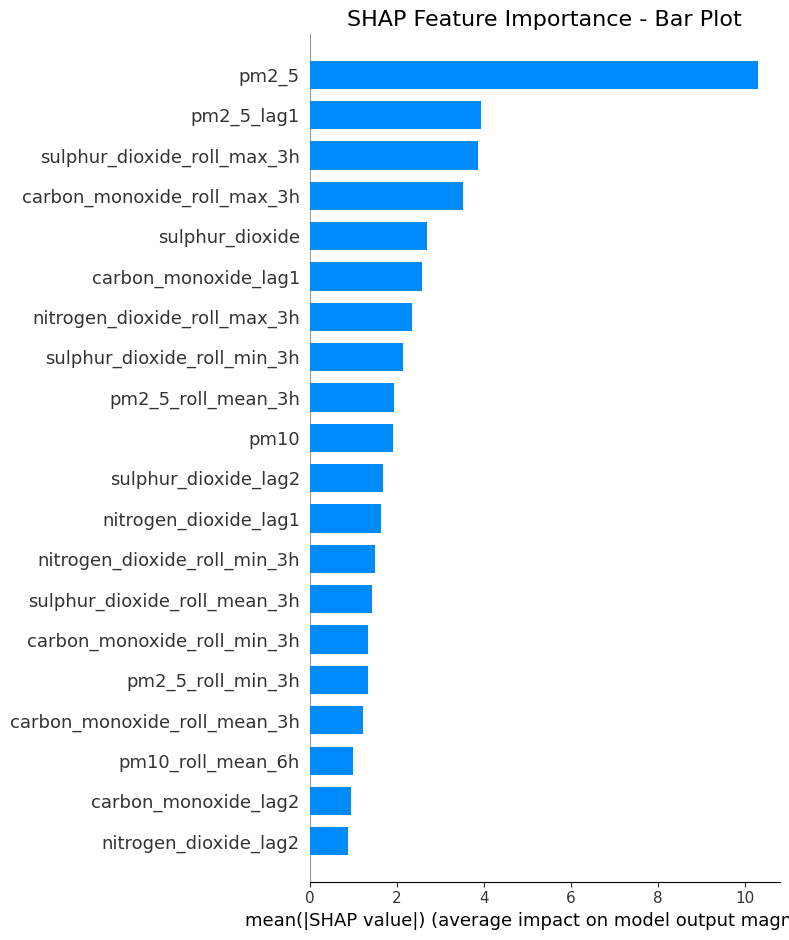

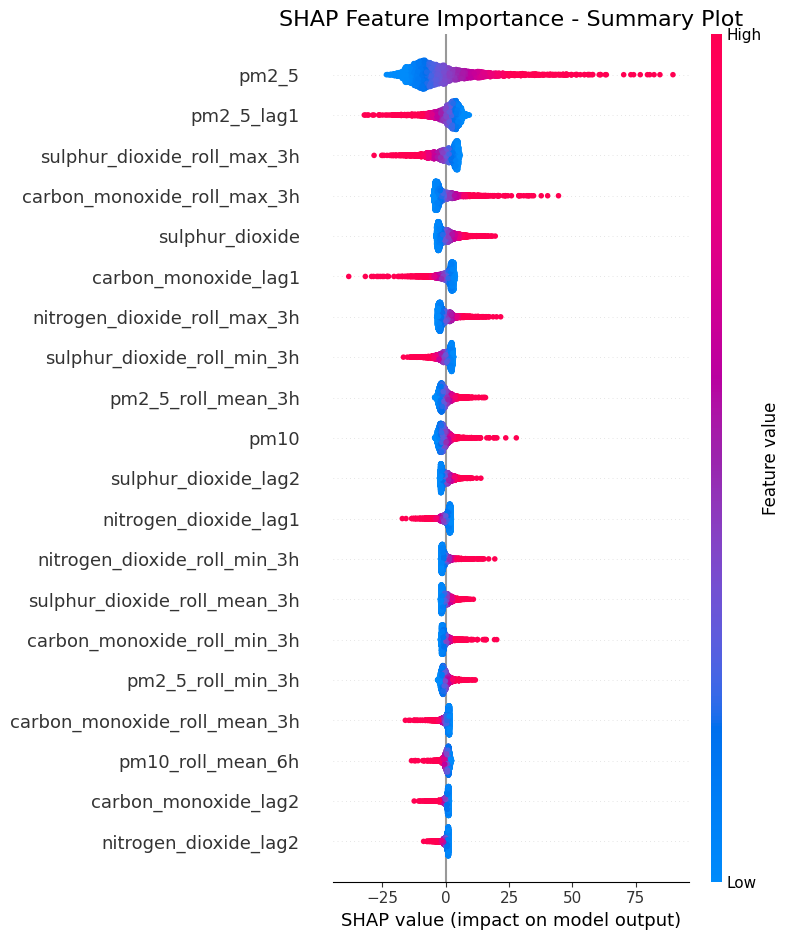

In [47]:
import shap
import joblib
import matplotlib.pyplot as plt

# Load your trained model
model = joblib.load("model/aqi_model.joblib")

# Load your training and test data
X_train = joblib.load("X_train.joblib")
X_test = joblib.load("X_test.joblib")

# Initialize SHAP explainer
explainer = shap.Explainer(model, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# SHAP Bar Plot (Feature Importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Bar Plot", fontsize=16)
plt.tight_layout()
plt.savefig("shap_feature_importance_bar.png")
plt.show()
plt.close()

# SHAP Summary Plot (Detailed Feature Impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance - Summary Plot", fontsize=16)
plt.tight_layout()
plt.savefig("shap_feature_importance_summary.png")
plt.show()
plt.close()

In [ ]:
# #Feature Pipeline

# def create_training_data(raw_df, window_days=3):
#     feature_rows = []
#     for i in range(window_days, len(raw_df)):
#         row = {}
#         window = raw_df.iloc[i - window_days:i]
#         row['mean_aqi'] = window['aqi'].mean()
#         row['max_aqi'] = window['aqi'].max()
#         row['min_aqi'] = window['aqi'].min()
#         row['aqi_change_rate'] = window['aqi'].diff().mean()
#         row['hour'] = raw_df.iloc[i]['hour']
#         row['day'] = raw_df.iloc[i]['day']
#         row['month'] = raw_df.iloc[i]['month']
#         row['target_aqi'] = raw_df.iloc[i]['aqi']
#         feature_rows.append(row)
#     return pd.DataFrame(feature_rows)

# df_features = create_training_data(df)
# df_features.to_csv('features_for_training.csv', index=False)


You have exceeded the maximum number of daily result records for your account.     0
dtype: int64
